## Referencia histórica — no ejecutar como pipeline vigente

Este cuadernillo conserva la lógica original y su estado de ejecución histórico, que puede ser parcial o contener errores antiguos. Se preserva para consulta; no se han regenerado sus exportaciones retiradas.

Las limpiezas oficiales **03/05** y los notebooks de análisis **06/07** contienen esa lógica contrastada y sus resultados están ejecutados. Para revisar el flujo actual completo, consultar `Notebooks/README.md` y `GUIA_PASO_A_PASO_DATOS_Y_MODELOS.md` de la raíz. No interpretar resultados antiguos como resultados de la base vigente.

# 3. Benchmark estimado vs. producción real

Este cuaderno deja visible la lógica de la sección **Unión de estimados y producción real para captar diferencias y definición de métricas semana a semana**. Usa las bases limpias ya exportadas, une primero por finca-producto-color-variedad y luego intenta recuperar pendientes por variedad.

La última celda genera `benchmark_salida`, incluyendo el Excel consolidado, las métricas, los pendientes y el informe HTML.

In [1]:
from pathlib import Path
import importlib.util
import json
import re
import unicodedata

import numpy as np
import pandas as pd

ROOT = next(r for r in [Path.cwd(), *Path.cwd().parents] if (r / 'Datos' / 'Estimados semanales').is_dir())
CARPETA_TRABAJO = ROOT / 'Notebooks' / 'Limpieza data, Notebooks y Scripts'
RUTA_ESTIMADOS = ROOT / 'Datos' / 'Estimados semanales' / 'datos extraidos' / 'estimados_crudos_h1_h5.csv'
CARPETA_PRODUCCION = next(p for p in (ROOT / 'Datos').iterdir() if 'PRODUCCION REAL' in ''.join(c for c in unicodedata.normalize('NFKD', p.name).upper() if not unicodedata.combining(c)))
RUTA_PRODUCCION = CARPETA_PRODUCCION / 'datos_limpios_multianual' / 'produccion_limpia_por_anio'
SALIDA = CARPETA_TRABAJO / 'benchmark_salida'
ANOS = range(2021, 2027)
LLAVE = ['anio', 'semana', 'k_finca', 'k_producto', 'k_color', 'k_variedad']
print('Estimados:', RUTA_ESTIMADOS)
print('Producción:', RUTA_PRODUCCION)

Estimados: C:\Materias y Cosas Técnicas Uniandes\Proyecto de grado\Proyecto de grado 2\Datos\Estimados semanales\datos extraidos\estimados_crudos_h1_h5.csv
Producción: C:\Materias y Cosas Técnicas Uniandes\Proyecto de grado\Proyecto de grado 2\Datos\Producción real\datos_limpios_multianual\produccion_limpia_por_anio


## 1. Preparación de las dos fuentes

Se toma únicamente H1 de los estimados para compararlo con la producción de la misma semana ISO. Los nombres se normalizan antes de unirlos; los faltantes de llave se excluyen y quedan contabilizados en el control.

In [2]:
def normalizar_texto(valor):
    if pd.isna(valor): return ''
    texto = ''.join(c for c in unicodedata.normalize('NFKD', str(valor).replace('\xa0', ' ').strip()) if not unicodedata.combining(c))
    return re.sub(r'\s+', ' ', texto).upper()

def limpiar_nombre(valor):
    texto = normalizar_texto(valor); return texto if texto else pd.NA

def limpiar_finca(valor):
    nombre = limpiar_nombre(valor)
    mapa = {'GF': 'GAITANA', 'LA GAITANA': 'GAITANA', 'GAITANA': 'GAITANA', 'AR': 'ARABELLA', 'ARABELLA': 'ARABELLA', 'CABANA': 'CABANA', 'LA CABANA': 'CABANA', 'FINCA LA CABANA': 'CABANA'}
    return mapa.get(nombre, nombre) if pd.notna(nombre) else pd.NA

estimados_original = pd.read_csv(RUTA_ESTIMADOS, low_memory=False)
estimados_original = estimados_original[estimados_original['horizonte'].astype(str).eq('1')].copy()
col_tallos_est = 'ESTI. EXPORTABLE' if 'ESTI. EXPORTABLE' in estimados_original.columns else 'tallos'
estimados = pd.DataFrame({'anio': pd.to_numeric(estimados_original['AÑO'], errors='coerce'), 'semana': pd.to_numeric(estimados_original['SEMANA'], errors='coerce'), 'k_finca': estimados_original['CODFINCA'].map(limpiar_finca), 'k_producto': estimados_original['PRODUCTO'].map(limpiar_nombre), 'k_color': estimados_original['COLOR'].map(limpiar_nombre), 'k_variedad': estimados_original['VARIEDAD'].map(limpiar_nombre), 'tallos_estimados': pd.to_numeric(estimados_original[col_tallos_est], errors='coerce')})
estimados = estimados.loc[estimados[LLAVE].notna().all(axis=1)].copy()

partes_produccion = []
for ano in ANOS:
    ruta = RUTA_PRODUCCION / f'produccion_limpia_{ano}.parquet'
    tabla = pd.read_parquet(ruta, columns=['Fecha Corte', 'anio_iso', 'semana_iso', 'Finca', 'Producto', 'Color', 'Variedad', 'Tallos'])
    tabla['fecha'] = pd.to_datetime(tabla['Fecha Corte'], errors='coerce')
    tabla['anio'] = pd.to_numeric(tabla['anio_iso'], errors='coerce'); tabla['semana'] = pd.to_numeric(tabla['semana_iso'], errors='coerce')
    tabla['k_finca'] = tabla['Finca'].map(limpiar_finca); tabla['k_producto'] = tabla['Producto'].map(limpiar_nombre); tabla['k_color'] = tabla['Color'].map(limpiar_nombre); tabla['k_variedad'] = tabla['Variedad'].map(limpiar_nombre); tabla['tallos_reales'] = pd.to_numeric(tabla['Tallos'], errors='coerce')
    partes_produccion.append(tabla)
produccion_detalle = pd.concat(partes_produccion, ignore_index=True)
produccion = produccion_detalle.loc[produccion_detalle[LLAVE].notna().all(axis=1)].groupby(LLAVE, as_index=False).agg(tallos_reales=('tallos_reales', 'sum'), fecha=('fecha', 'max'))
print('Filas estimados H1 válidas:', len(estimados)); print('Filas producción agregadas:', len(produccion))

Filas estimados H1 válidas: 32604
Filas producción agregadas: 57460


## 2. Unión estricta y recuperación por variedad

La unión estricta conserva el color. Para pendientes, se agrupa por variedad ignorando el color y se marca `unido_variedad`; esto permite captar diferencias de codificación de color sin convertir faltantes en ceros.

In [3]:
cabana_est = estimados['k_finca'].eq('CABANA').fillna(False); cabana_prod = produccion['k_finca'].eq('CABANA').fillna(False)
control_cabana = pd.DataFrame({'fuente': ['estimado', 'produccion'], 'filas_excluidas': [int(cabana_est.sum()), int(cabana_prod.sum())], 'tallos_excluidos': [estimados.loc[cabana_est, 'tallos_estimados'].sum(min_count=1), produccion.loc[cabana_prod, 'tallos_reales'].sum(min_count=1)]})
estimado = estimados.loc[~cabana_est].copy(); real = produccion.loc[~cabana_prod].copy()
fecha_maxima_produccion = real['fecha'].max(); lunes_corte = pd.Timestamp.fromisocalendar(fecha_maxima_produccion.isocalendar().year, fecha_maxima_produccion.isocalendar().week, 1)
lunes_estimado = pd.to_datetime(estimado['anio'].astype('Int64').astype(str) + '-W' + estimado['semana'].astype('Int64').astype(str).str.zfill(2) + '-1', format='%G-W%V-%u', errors='coerce')
fuera_corte = lunes_estimado > lunes_corte; invalidas_fecha = lunes_estimado.isna()
control_exclusiones_estimados = pd.DataFrame([{'motivo': f'Posterior a {fecha_maxima_produccion.date()}', 'filas': int(fuera_corte.sum()), 'tallos': estimado.loc[fuera_corte, 'tallos_estimados'].sum(min_count=1)}, {'motivo': 'Año o semana inválidos', 'filas': int(invalidas_fecha.sum()), 'tallos': estimado.loc[invalidas_fecha, 'tallos_estimados'].sum(min_count=1)}])
estimado = estimado.loc[~fuera_corte & ~invalidas_fecha].copy()
est_agregado = estimado.groupby(LLAVE, as_index=False).agg(tallos_estimados=('tallos_estimados', 'sum'))
real_agregado = real.groupby(LLAVE, as_index=False).agg(tallos_reales=('tallos_reales', 'sum'))
union = est_agregado.merge(real_agregado, on=LLAVE, how='outer', indicator=True)
union['estado'] = union['_merge'].map({'both': 'coincide', 'left_only': 'solo_estimado', 'right_only': 'solo_produccion'}); union = union.drop(columns='_merge')
coincidencias = union[union['estado'].eq('coincide')].copy(); est_pendiente = union[union['estado'].eq('solo_estimado')].copy(); prod_pendiente = union[union['estado'].eq('solo_produccion')].copy()
llave_variedad = ['anio', 'semana', 'k_finca', 'k_producto', 'k_variedad']
est_var = est_pendiente.groupby(llave_variedad, as_index=False).agg(k_color=('k_color', 'first'), tallos_estimados=('tallos_estimados', 'sum'))
prod_var = prod_pendiente.groupby(llave_variedad, as_index=False).agg(k_color=('k_color', 'first'), tallos_reales=('tallos_reales', 'sum'))
recuperadas = est_var.merge(prod_var, on=llave_variedad, how='outer', indicator=True, suffixes=('_est', '_prod'))
recuperadas['k_color'] = recuperadas['k_color_est'].combine_first(recuperadas['k_color_prod']); recuperadas['estado'] = recuperadas['_merge'].map({'both': 'unido_variedad', 'left_only': 'solo_estimado', 'right_only': 'solo_produccion'})
recuperadas = recuperadas[LLAVE + ['tallos_estimados', 'tallos_reales', 'estado']]
benchmark = pd.concat([coincidencias, recuperadas], ignore_index=True)[LLAVE + ['tallos_estimados', 'tallos_reales', 'estado']].sort_values(LLAVE).reset_index(drop=True)
control_union = {'coincidencias_estrictas': len(coincidencias), 'solo_estimado_estricta': len(est_pendiente), 'solo_produccion_estricta': len(prod_pendiente), 'recuperadas_por_variedad': int((recuperadas['estado'] == 'unido_variedad').sum())}
print('Benchmark:', len(benchmark), 'filas'); display(pd.Series(control_union).to_frame('valor'))

Benchmark: 60492 filas


,valor
coincidencias_estrictas,27018
solo_estimado_estricta,4635
solo_produccion_estricta,30442
recuperadas_por_variedad,1558


## 3. Métricas, pendientes y HTML

In [4]:
metricas = benchmark.copy(); metricas['comparacion_valida'] = metricas['estado'].isin(['coincide', 'unido_variedad']); metricas['estimado_metricas'] = metricas['tallos_estimados'].fillna(0); metricas['real_metricas'] = metricas['tallos_reales'].fillna(0); metricas['diferencia_tallos'] = metricas['real_metricas'] - metricas['estimado_metricas']; metricas['error_absoluto'] = metricas['diferencia_tallos'].abs()
filas = []
for (anio, semana), grupo in metricas.groupby(['anio', 'semana']):
    comparado = grupo[grupo['comparacion_valida']]; real_semana = comparado['tallos_reales'].sum(min_count=1); error = comparado['error_absoluto'].sum(min_count=1); diferencia = comparado['diferencia_tallos'].sum(min_count=1)
    filas.append({'anio': anio, 'semana': semana, 'registros': len(grupo), 'comparaciones': len(comparado), 'por_revisar': int((~grupo['comparacion_valida']).sum()), 'tallos_estimados': grupo['tallos_estimados'].sum(min_count=1), 'tallos_reales': grupo['tallos_reales'].sum(min_count=1), 'diferencia_tallos': diferencia, 'error_absoluto_total': error, 'MAE_tallos': comparado['error_absoluto'].mean() if len(comparado) else pd.NA, 'WAPE_pct': error / real_semana * 100 if pd.notna(real_semana) and real_semana else pd.NA, 'sesgo_pct': diferencia / real_semana * 100 if pd.notna(real_semana) and real_semana else pd.NA, 'cobertura_pct': len(comparado) / len(grupo) * 100 if len(grupo) else pd.NA})
metricas_semanales = pd.DataFrame(filas).sort_values(['anio', 'semana']).reset_index(drop=True)
pendientes_semana = benchmark.assign(fuente=benchmark['estado'].map({'solo_produccion': 'Produccion sin estimado', 'solo_estimado': 'Estimado sin produccion'})).dropna(subset=['fuente']).groupby(['anio', 'semana', 'fuente'], as_index=False).agg(registros=('estado', 'size'), tallos=('tallos_reales', lambda s: s.sum(min_count=1)), tallos_estimados=('tallos_estimados', lambda s: s.sum(min_count=1)))
control_benchmark = pd.DataFrame([{**control_union, 'filas_estimados_h1': len(estimados), 'filas_produccion_agregada': len(produccion), 'fecha_maxima_produccion': fecha_maxima_produccion}])
SALIDA.mkdir(parents=True, exist_ok=True)
salidas = {'benchmark': benchmark, 'metricas_semanales': metricas_semanales, 'pendientes_semana': pendientes_semana, 'control_estimados': pd.DataFrame({'filas_h1_originales': [len(estimados_original)], 'filas_h1_llave_valida': [len(estimados)]}), 'control_cabana': control_cabana, 'control_exclusiones_estimados': control_exclusiones_estimados, 'control_benchmark': control_benchmark}
for nombre, tabla in salidas.items(): tabla.to_csv(SALIDA / f'{nombre}.csv', index=False, encoding='utf-8-sig')
archivo_excel = SALIDA / 'benchmark_consolidado.xlsx'; benchmark.to_excel(archivo_excel, index=False)
ruta_generador = ROOT / 'scripts' / 'generar_informe_benchmark.py'; spec = importlib.util.spec_from_file_location('generador_informe_benchmark', ruta_generador); generador = importlib.util.module_from_spec(spec); spec.loader.exec_module(generador)
informe = generador.generar_informe(archivo=archivo_excel, salida=SALIDA, notebook=CARPETA_TRABAJO / '3_Benchmark estimado ingeniero.ipynb')
(SALIDA / 'manifest.json').write_text(json.dumps({'fuente_estimados': str(RUTA_ESTIMADOS), 'fuente_produccion': str(RUTA_PRODUCCION), 'filas_benchmark': len(benchmark), 'html': str(informe['html']), 'excel_informe': str(informe['excel'])}, ensure_ascii=False, indent=2), encoding='utf-8')
print('HTML:', informe['html']); print('Excel:', informe['excel']); display(metricas_semanales.head(10))

HTML: C:\Materias y Cosas Técnicas Uniandes\Proyecto de grado\Proyecto de grado 2\Notebooks\Limpieza data, Notebooks y Scripts\benchmark_salida\informe_gerencia_benchmark.html
Excel: C:\Materias y Cosas Técnicas Uniandes\Proyecto de grado\Proyecto de grado 2\Notebooks\Limpieza data, Notebooks y Scripts\benchmark_salida\informe_gerencia_benchmark.xlsx


,anio,semana,registros,comparaciones,por_revisar,tallos_estimados,tallos_reales,diferencia_tallos,error_absoluto_total,MAE_tallos,WAPE_pct,sesgo_pct,cobertura_pct
0,2021,1,144,0,144,NaN,1485495,<NA>,<NA>,<NA>,<NA>,<NA>,0.0
1,2021,2,146,0,146,NaN,1471021,<NA>,<NA>,<NA>,<NA>,<NA>,0.0
2,2021,3,141,0,141,NaN,1315154,<NA>,<NA>,<NA>,<NA>,<NA>,0.0
3,2021,4,141,0,141,NaN,1201597,<NA>,<NA>,<NA>,<NA>,<NA>,0.0
4,2021,5,145,0,145,NaN,1084716,<NA>,<NA>,<NA>,<NA>,<NA>,0.0
5,2021,6,173,0,173,NaN,1215941,<NA>,<NA>,<NA>,<NA>,<NA>,0.0
6,2021,7,183,0,183,NaN,1159668,<NA>,<NA>,<NA>,<NA>,<NA>,0.0
7,2021,8,186,0,186,NaN,1000619,<NA>,<NA>,<NA>,<NA>,<NA>,0.0
8,2021,9,188,0,188,NaN,912221,<NA>,<NA>,<NA>,<NA>,<NA>,0.0
9,2021,10,197,0,197,NaN,1028006,<NA>,<NA>,<NA>,<NA>,<NA>,0.0


## 4. Revisión rápida de 2026-S02 y curva semanal

,anio,semana,registros,comparaciones,por_revisar,tallos_estimados,tallos_reales,diferencia_tallos,error_absoluto_total,MAE_tallos,WAPE_pct,sesgo_pct,cobertura_pct
259,2026,1,256,169,87,1443910.0,1393109,-58846.0,324258.0,1918.686391,23.413077,-4.24898,66.015625
260,2026,2,233,0,233,NaN,1402826,<NA>,<NA>,<NA>,<NA>,<NA>,0.000000
261,2026,3,256,169,87,1696761.0,1685938,-18283.0,337027.0,1994.242604,20.0798,-1.089287,66.015625


,anio,semana,k_finca,k_producto,k_color,k_variedad,tallos_estimados,tallos_reales,estado
52004,2026,2,ARABELLA,CARNATION,BICOLOR BURGUNDY,MERLETTO CRIMSON,NaN,4406,solo_produccion
52005,2026,2,ARABELLA,CARNATION,BICOLOR BURGUNDY,PERFECT,NaN,11875,solo_produccion
52006,2026,2,ARABELLA,CARNATION,BICOLOR PINK,ANTIGUA,NaN,6763,solo_produccion
52007,2026,2,ARABELLA,CARNATION,BICOLOR PINK,SPRITZ BIANCO ROSA,NaN,6091,solo_produccion
52008,2026,2,ARABELLA,CARNATION,BICOLOR PURPLE,DAMASCUS,NaN,6394,solo_produccion
52009,2026,2,ARABELLA,CARNATION,BICOLOR PURPLE,KINO,NaN,4645,solo_produccion
52010,2026,2,ARABELLA,CARNATION,BICOLOR RED,SORRISO,NaN,10111,solo_produccion
52011,2026,2,ARABELLA,CARNATION,BICOLOR YELLOW,SPRITZ,NaN,4531,solo_produccion
52012,2026,2,ARABELLA,CARNATION,BICOLOR YELLOW,ZENIT,NaN,11539,solo_produccion
52013,2026,2,ARABELLA,CARNATION,BURGUNDY,ZURIGO,NaN,8499,solo_produccion


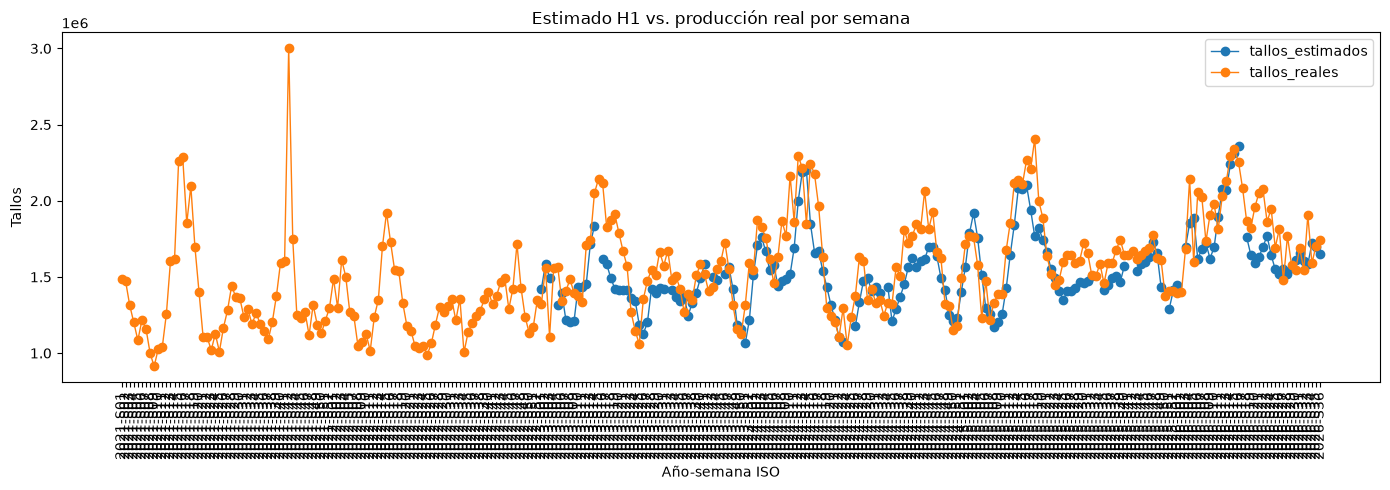

In [5]:
display(metricas_semanales[(metricas_semanales['anio'] == 2026) & (metricas_semanales['semana'] <= 3)])
display(benchmark[(benchmark['anio'] == 2026) & (benchmark['semana'] == 2)].head(20))
import matplotlib.pyplot as plt
curva = metricas_semanales.melt(id_vars=['anio', 'semana'], value_vars=['tallos_estimados', 'tallos_reales'], var_name='fuente', value_name='tallos'); curva['periodo'] = curva['anio'].astype(str) + '-S' + curva['semana'].astype(str).str.zfill(2)
plt.figure(figsize=(14, 5));
for fuente, bloque in curva.groupby('fuente'): plt.plot(bloque['periodo'], bloque['tallos'], marker='o', linewidth=1, label=fuente)
plt.xticks(rotation=90); plt.title('Estimado H1 vs. producción real por semana'); plt.xlabel('Año-semana ISO'); plt.ylabel('Tallos'); plt.legend(); plt.tight_layout(); plt.show()